In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE  

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.3, .7])

# Define means
means = jnp.array([
    [1., 0.],   # mean of first Gaussian
    [-1., 0.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

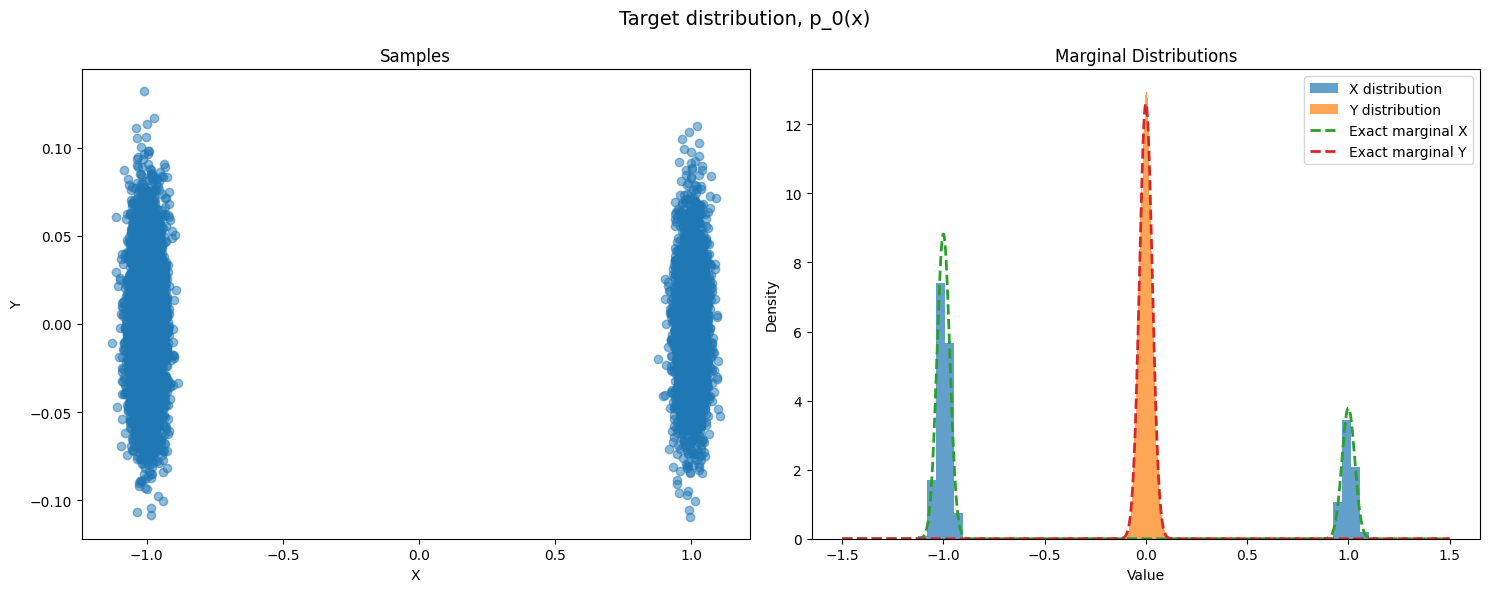

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Network size and topology

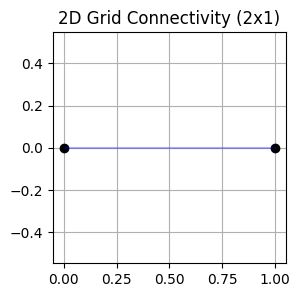

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
bias_0 = jnp.array([0.,0.,])
params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, bias_0)
params_names = ["k_lin", "k_duff", "c_lin", "c_optomech", "external_force"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)

### Build energy

In [6]:
energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


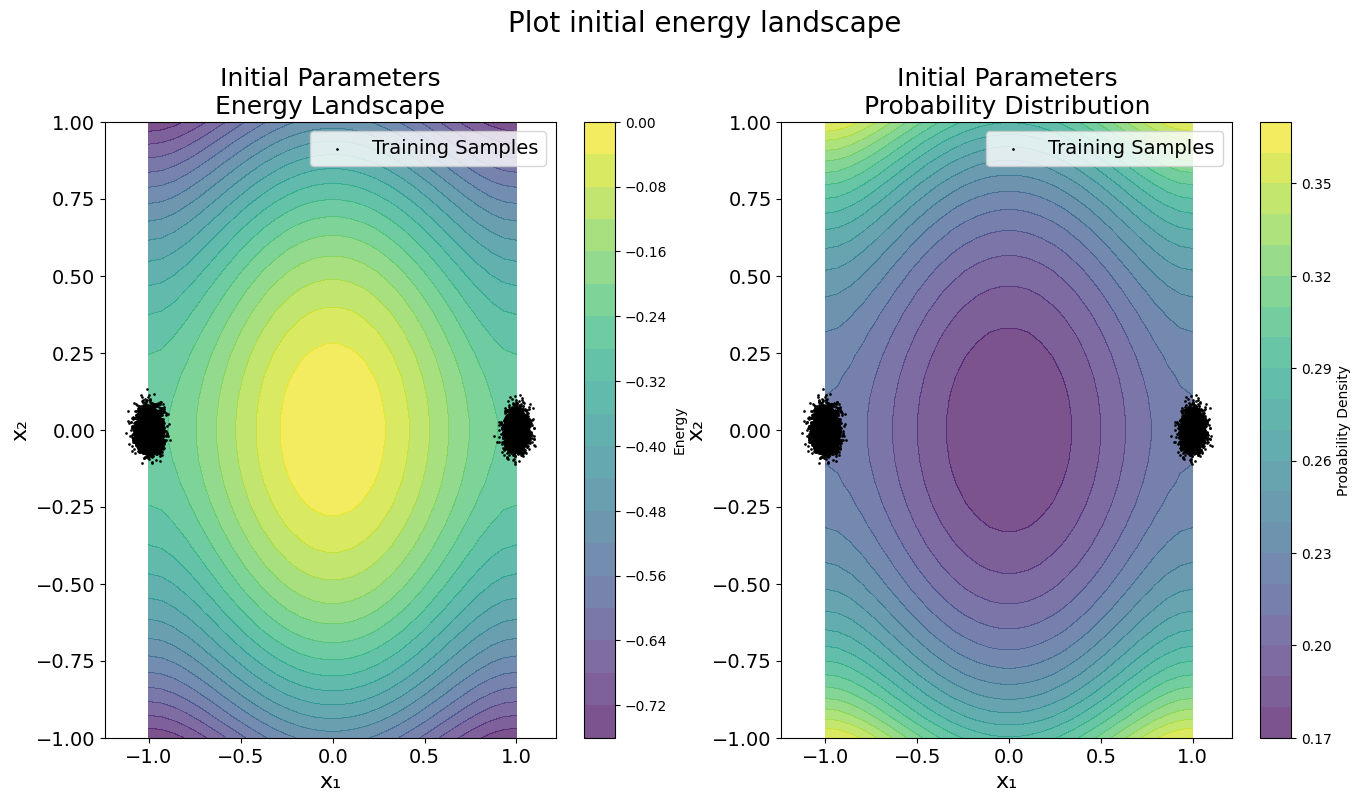

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 50
t_forward = 1.0
sigma_forward = .5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-20), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = 1.
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = "with_external_force"
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.3 0.7]_means_[ 1.  0. -1.  0.]/SM_t_forward_1.0_n_timesteps_50_lr_1.0_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_with_external_force


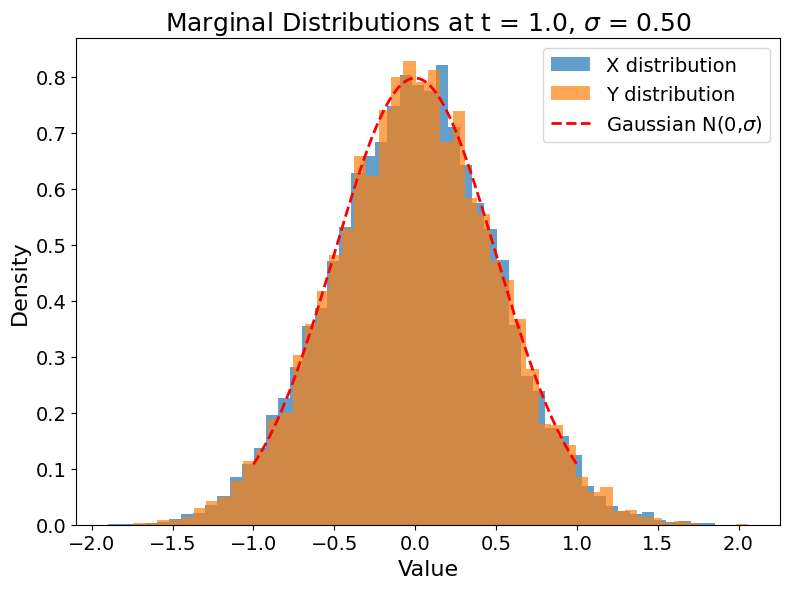

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: -1.0075
Epoch 100 - Loss: -244.6760
Epoch 200 - Loss: -424.7861
Epoch 300 - Loss: -567.2531
Epoch 400 - Loss: -663.4618
Epoch 500 - Loss: -751.9615
Epoch 600 - Loss: -797.7984
Epoch 700 - Loss: -856.4851
Epoch 800 - Loss: -897.1867
Epoch 900 - Loss: -828.5947
Epoch 1000 - Loss: -936.4932
Epoch 1100 - Loss: -935.6472
Epoch 1200 - Loss: -991.0373
Epoch 1300 - Loss: -988.8125
Epoch 1400 - Loss: -1008.3874
Epoch 1500 - Loss: -1084.8227
Epoch 1600 - Loss: -975.4691
Epoch 1700 - Loss: -981.7331
Epoch 1800 - Loss: -1021.2529
Epoch 1900 - Loss: -919.3595
Epoch 2000 - Loss: -1048.8893
Epoch 2100 - Loss: -844.9155
Epoch 2200 - Loss: -1045.1341
Epoch 2300 - Loss: -1047.7867
Epoch 2400 - Loss: -935.8600
Epoch 2500 - Loss: -943.2932
Epoch 2600 - Loss: -935.5056
Epoch 2700 - Loss: -1089.7090
Epoch 2800 - Loss: -1008.9441
Epoch 2900 - Loss: -986.4327
Epoch 3000 - Loss: -1017.7301
Epoch 3100 - Loss: -1043.4826
Epoch 3200 - Loss: -1029.3673
Epoch 3300 - Loss: -

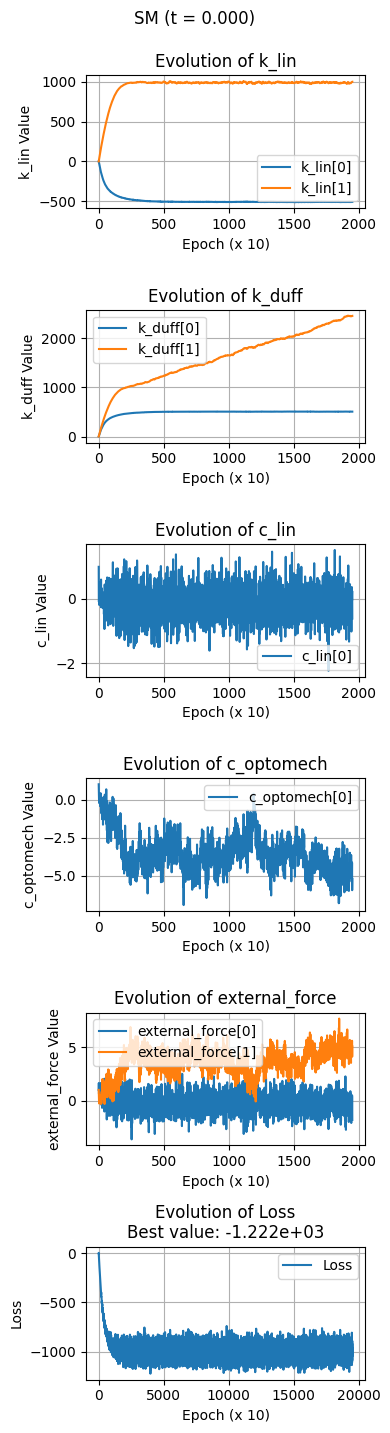

Optimization for time 2.5595479226995292e-20
Epoch 0 - Loss: -986.6322
Epoch 100 - Loss: -1044.1316
Epoch 200 - Loss: -1099.8328
Epoch 300 - Loss: -993.6797
Epoch 400 - Loss: -897.7058
Epoch 500 - Loss: -946.3443
Epoch 600 - Loss: -949.2342
Epoch 700 - Loss: -1031.9528
Epoch 800 - Loss: -1007.7374
Epoch 900 - Loss: -1186.4060
Epoch 1000 - Loss: -944.0048
Epoch 1100 - Loss: -993.0180
Epoch 1200 - Loss: -1009.6961
Epoch 1300 - Loss: -908.2077
Epoch 1400 - Loss: -1071.5123
Epoch 1500 - Loss: -977.9641
Epoch 1600 - Loss: -954.9839
Epoch 1700 - Loss: -991.9631
Epoch 1800 - Loss: -932.3931
Epoch 1900 - Loss: -1032.4711
Epoch 2000 - Loss: -852.8391
Epoch 2100 - Loss: -1071.2202
Epoch 2200 - Loss: -940.9164
Epoch 2300 - Loss: -895.4084
Epoch 2400 - Loss: -1029.4517
Epoch 2500 - Loss: -1071.6174
Epoch 2600 - Loss: -911.9715
Epoch 2700 - Loss: -1104.8253
Epoch 2800 - Loss: -908.4014
Epoch 2900 - Loss: -863.1186
Epoch 3000 - Loss: -924.7724
Epoch 3100 - Loss: -980.8656
Epoch 3200 - Loss: -982.522

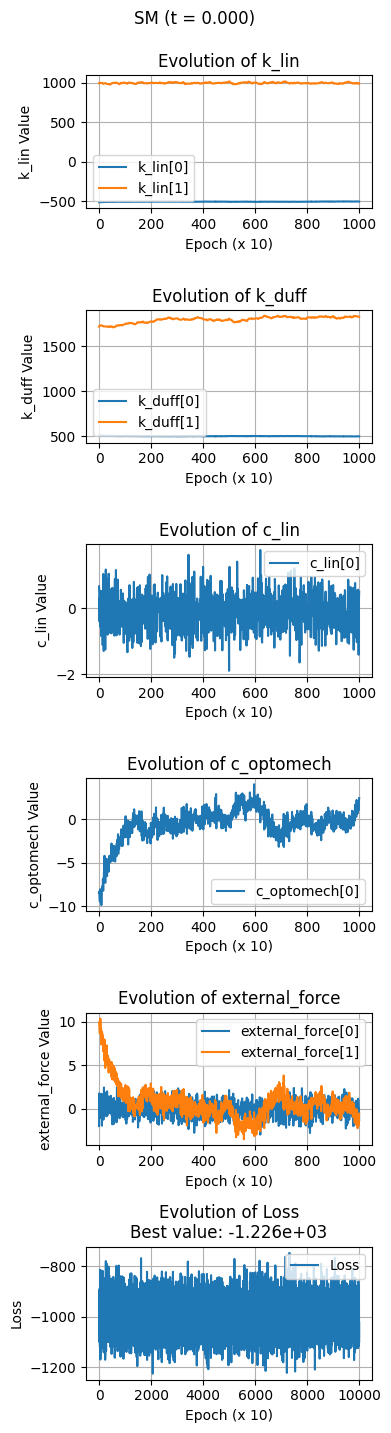

Optimization for time 3.0888435964774857e-16
Epoch 0 - Loss: -972.6690
Epoch 100 - Loss: -1028.4069
Epoch 200 - Loss: -1181.1055
Epoch 300 - Loss: -1026.8930
Epoch 400 - Loss: -1065.5372
Epoch 500 - Loss: -1077.8306
Epoch 600 - Loss: -890.5038
Epoch 700 - Loss: -1020.7067
Epoch 800 - Loss: -1088.0514
Epoch 900 - Loss: -1042.6101
Epoch 1000 - Loss: -1044.6978
Epoch 1100 - Loss: -911.9288
Epoch 1200 - Loss: -958.8110
Epoch 1300 - Loss: -1028.2834
Epoch 1400 - Loss: -994.7813
Epoch 1500 - Loss: -1003.9076
Epoch 1600 - Loss: -1049.6574
Epoch 1700 - Loss: -1091.4185
Epoch 1800 - Loss: -994.5368
Epoch 1900 - Loss: -1021.1571
Epoch 2000 - Loss: -908.3552
Epoch 2100 - Loss: -1034.6397
Epoch 2200 - Loss: -1071.1309
Epoch 2300 - Loss: -960.1776
Epoch 2400 - Loss: -970.8853
Epoch 2500 - Loss: -1037.9008
Epoch 2600 - Loss: -1063.1538
Epoch 2700 - Loss: -1111.1037
Epoch 2800 - Loss: -1017.7841
Epoch 2900 - Loss: -961.5873
Epoch 3000 - Loss: -956.7110
Epoch 3100 - Loss: -976.4124
Epoch 3200 - Loss: 

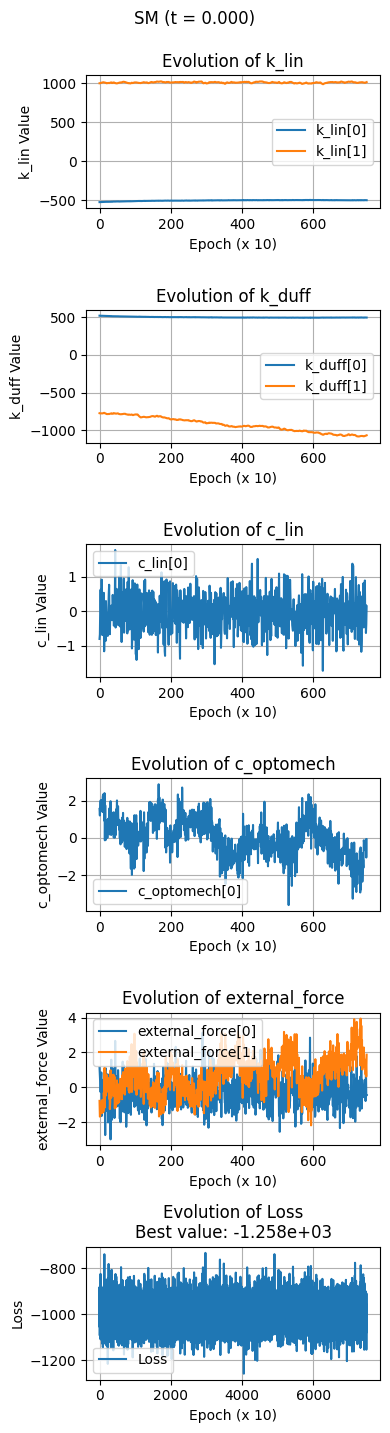

Optimization for time 3.727593720314922e-12
Epoch 0 - Loss: -871.9559
Epoch 100 - Loss: -986.6377
Epoch 200 - Loss: -929.9406
Epoch 300 - Loss: -960.2011
Epoch 400 - Loss: -1015.3815
Epoch 500 - Loss: -1056.4751
Epoch 600 - Loss: -971.0794
Epoch 700 - Loss: -1075.2760
Epoch 800 - Loss: -981.5150
Epoch 900 - Loss: -944.4633
Epoch 1000 - Loss: -1064.7534
Epoch 1100 - Loss: -910.3078
Epoch 1200 - Loss: -1005.6616
Epoch 1300 - Loss: -924.6811
Epoch 1400 - Loss: -1109.6763
Epoch 1500 - Loss: -1038.2690
Epoch 1600 - Loss: -1076.2815
Epoch 1700 - Loss: -894.5140
Epoch 1800 - Loss: -1012.2484
Epoch 1900 - Loss: -1070.0241
Epoch 2000 - Loss: -951.5003
Epoch 2100 - Loss: -1026.1963
Epoch 2200 - Loss: -946.2254
Epoch 2300 - Loss: -995.2447
Epoch 2400 - Loss: -1002.5972
Epoch 2500 - Loss: -1006.2407
Epoch 2600 - Loss: -998.4199
Epoch 2700 - Loss: -1044.0510
Epoch 2800 - Loss: -1005.2234
Epoch 2900 - Loss: -989.3378
Epoch 3000 - Loss: -957.5683
Epoch 3100 - Loss: -1013.0478
Epoch 3200 - Loss: -1026

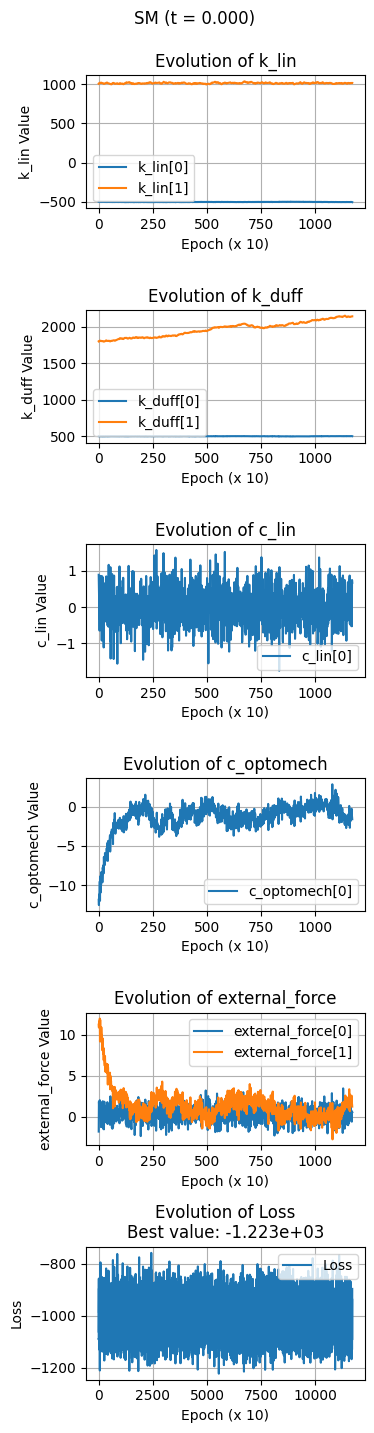

Optimization for time 4.4984326689694254e-08
Epoch 0 - Loss: -1027.0433
Epoch 100 - Loss: -1039.6152
Epoch 200 - Loss: -1031.9666
Epoch 300 - Loss: -1007.5937
Epoch 400 - Loss: -1065.9418
Epoch 500 - Loss: -914.8939
Epoch 600 - Loss: -1016.8689
Epoch 700 - Loss: -1084.2352
Epoch 800 - Loss: -904.2222
Epoch 900 - Loss: -1028.2028
Epoch 1000 - Loss: -978.4927
Epoch 1100 - Loss: -1040.0383
Epoch 1200 - Loss: -967.5286
Epoch 1300 - Loss: -1032.2273
Epoch 1400 - Loss: -1048.3086
Epoch 1500 - Loss: -1034.5202
Epoch 1600 - Loss: -956.8116
Epoch 1700 - Loss: -1041.3040
Epoch 1800 - Loss: -1026.6663
Epoch 1900 - Loss: -966.8641
Epoch 2000 - Loss: -945.7061
Epoch 2100 - Loss: -985.1963
Epoch 2200 - Loss: -881.7178
Epoch 2300 - Loss: -1018.6339
Epoch 2400 - Loss: -971.6347
Epoch 2500 - Loss: -898.6791
Epoch 2600 - Loss: -1110.1154
Epoch 2700 - Loss: -1078.5740
Epoch 2800 - Loss: -975.0890
Epoch 2900 - Loss: -958.4840
Epoch 3000 - Loss: -1039.6655
Epoch 3100 - Loss: -953.6774
Epoch 3200 - Loss: -9

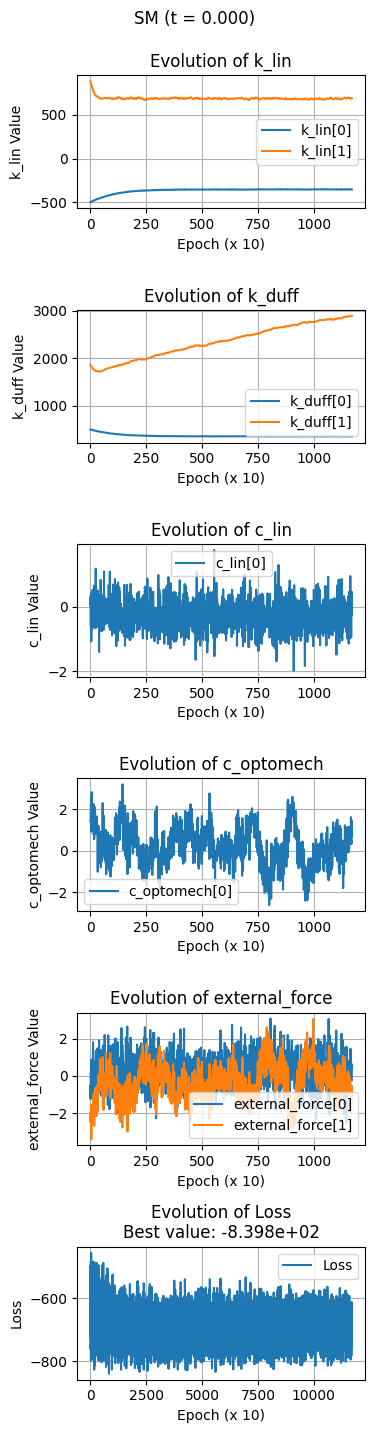

Optimization for time 0.0005428675439323843
Epoch 0 - Loss: -298.1563
Epoch 100 - Loss: -436.0332
Epoch 200 - Loss: -380.0649
Epoch 300 - Loss: -518.2935
Epoch 400 - Loss: -423.5534
Epoch 500 - Loss: -441.5750
Epoch 600 - Loss: -449.9995
Epoch 700 - Loss: -450.8560
Epoch 800 - Loss: -443.8808
Epoch 900 - Loss: -523.7851
Epoch 1000 - Loss: -491.9502
Epoch 1100 - Loss: -475.9453
Epoch 1200 - Loss: -464.2469
Epoch 1300 - Loss: -490.7745
Epoch 1400 - Loss: -494.6658
Epoch 1500 - Loss: -460.7420
Epoch 1600 - Loss: -416.1231
Epoch 1700 - Loss: -471.3854
Epoch 1800 - Loss: -517.0613
Epoch 1900 - Loss: -474.0046
Epoch 2000 - Loss: -404.8487
Epoch 2100 - Loss: -461.5453
Epoch 2200 - Loss: -427.3136
Epoch 2300 - Loss: -501.1613
Epoch 2400 - Loss: -508.0629
Epoch 2500 - Loss: -519.6562
Epoch 2600 - Loss: -511.7662
Epoch 2700 - Loss: -452.4627
Epoch 2800 - Loss: -466.2890
Epoch 2900 - Loss: -495.1066
Epoch 3000 - Loss: -432.7053
Epoch 3100 - Loss: -513.6571
Epoch 3200 - Loss: -438.7594
Epoch 3300 

In [ ]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[-1].set(0.0)
    

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

In [ ]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [15]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params

In [ ]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [ ]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 1000  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


In [ ]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

In [ ]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()